##🛡️ RNN Email Spam Classifier
Bidirectional LSTM with TensorFlow / Keras
Dataset: spam_or_not_spam.csv — 3,000 emails (2,500 Ham · 500 Spam)
Architecture: Embedding → SpatialDropout1D → BiLSTM → GlobalMaxPooling → Dense
Goal: Binary classification — detect spam emails with high precision and recall

In [3]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    Bidirectional, SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(" All libraries imported successfully")
print(f"   TensorFlow version : {tf.__version__}")


 All libraries imported successfully
   TensorFlow version : 2.19.0


##  Hyper-parameters

In [4]:

VOCAB_SIZE  = 8_000   # top N words kept in vocabulary
MAX_LEN     = 150     # tokens per email (truncate / pad)
EMBED_DIM   = 32      # embedding vector dimension
LSTM_UNITS  = 32      # LSTM hidden units (each direction)
BATCH_SIZE  = 128
EPOCHS      = 15

print(f"Vocab size  : {VOCAB_SIZE:,}")
print(f"Seq length  : {MAX_LEN}")
print(f"Embed dim   : {EMBED_DIM}")
print(f"LSTM units  : {LSTM_UNITS}  (Bidirectional → {LSTM_UNITS*2} total)")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Max epochs  : {EPOCHS}")


Vocab size  : 8,000
Seq length  : 150
Embed dim   : 32
LSTM units  : 32  (Bidirectional → 64 total)
Batch size  : 128
Max epochs  : 15


## Load & Explore Dataset

In [5]:

df = pd.read_csv('spam_or_not_spam.csv')
df['email'] = df['email'].fillna('').astype(str)

print(f"Total emails : {len(df):,}")
print(f"Columns      : {df.columns.tolist()}")
print()
print(df['label'].value_counts().rename({0:'Ham (not spam)', 1:'Spam'}))
print()
df.head()


Total emails : 3,000
Columns      : ['email', 'label']

label
Ham (not spam)    2500
Spam               500
Name: count, dtype: int64



,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


###  Class Distribution

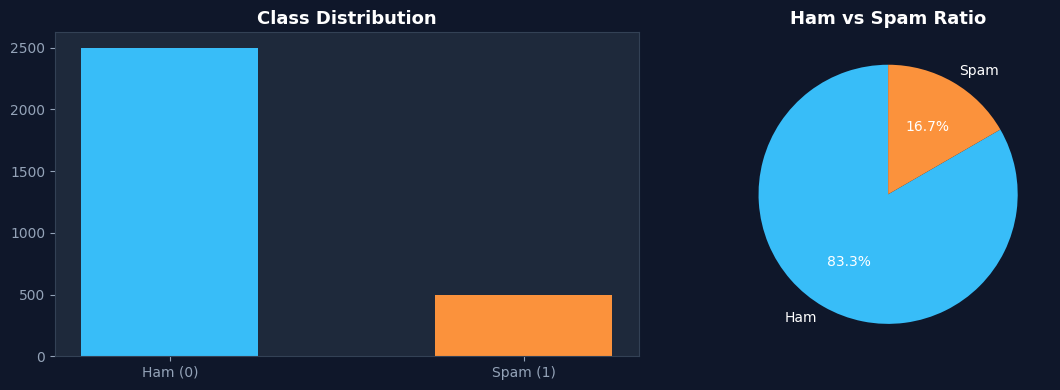


Class imbalance ratio  →  Ham : Spam = 5 : 1


In [6]:
# ── 4. Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0f172a')
counts = df['label'].value_counts()
colors = ['#38bdf8', '#fb923c']

axes[0].bar(['Ham (0)', 'Spam (1)'], counts.values, color=colors, edgecolor='none', width=0.5)
axes[0].set_facecolor('#1e293b')
axes[0].set_title('Class Distribution', color='white', fontsize=13, fontweight='bold')
axes[0].tick_params(colors='#94a3b8')
for spine in axes[0].spines.values(): spine.set_edgecolor('#334155')

axes[1].pie(counts.values, labels=['Ham', 'Spam'], colors=colors,
            autopct='%1.1f%%', textprops={'color': 'white'}, startangle=90)
axes[1].set_facecolor('#1e293b')
axes[1].set_title('Ham vs Spam Ratio', color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\nClass imbalance ratio  →  Ham : Spam = {counts[0]//counts[1]} : 1")


##  Text Preprocessing — Tokenization & Padding

In [7]:

X = df['email'].values
y = df['label'].values

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X)

seqs  = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

actual_vocab = min(len(tokenizer.word_index) + 1, VOCAB_SIZE)
print(f"Unique words found : {len(tokenizer.word_index):,}")
print(f"Vocab kept (capped): {actual_vocab:,}")
print(f"Padded shape       : {X_pad.shape}")
print()
print("Sample token sequence (first email, first 20 tokens):")
print(X_pad[0, :20])


Unique words found : 33,673
Vocab kept (capped): 8,000
Padded shape       : (3000, 150)

Sample token sequence (first email, first 20 tokens):
[  89  577    2  380    2    2    2    2    2   22  535 1399 3054 2481
    2    1 2422  175   91  932]


##  Train / Validation / Test Split (80 / 10 / 10)

In [8]:
#  6. Split
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_pad, y, test_size=0.20, random_state=SEED, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f"Training   : {len(X_tr):>5,} samples  |  Spam: {y_tr.sum():>3}")
print(f"Validation : {len(X_val):>5,} samples  |  Spam: {y_val.sum():>3}")
print(f"Test       : {len(X_te):>5,} samples  |  Spam: {y_te.sum():>3}")


Training   : 2,400 samples  |  Spam: 400
Validation :   300 samples  |  Spam:  50
Test       :   300 samples  |  Spam:  50


##  Build the BiLSTM Model

In [9]:
#  7. Build model
model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True,
                       dropout=0.2, recurrent_dropout=0.2)),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='BiLSTM_SpamDetector')

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()


Model: "BiLSTM_SpamDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##  Class Weights (handle 5:1 imbalance)

In [10]:
# ── 8. Class weights
neg, pos = np.bincount(y_tr)
w_spam   = neg / pos
class_weight = {0: 1.0, 1: w_spam}

print(f"Ham  weight : 1.00")
print(f"Spam weight : {w_spam:.2f}  (penalises missing spam {w_spam:.1f}x more)")


Ham  weight : 1.00
Spam weight : 5.00  (penalises missing spam 5.0x more)


##  Train the Model

In [11]:
# 9. Callbacks & training
callbacks = [
    EarlyStopping(monitor='val_auc', patience=4,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 229ms/step - accuracy: 0.5858 - auc: 0.6475 - loss: 1.1475 - val_accuracy: 0.8900 - val_auc: 0.8712 - val_loss: 0.6681 - learning_rate: 0.0010
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.8667 - auc: 0.8860 - loss: 1.0939 - val_accuracy: 0.9400 - val_auc: 0.9478 - val_loss: 0.5853 - learning_rate: 0.0010
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - accuracy: 0.9279 - auc: 0.9546 - loss: 0.6529 - val_accuracy: 0.9633 - val_auc: 0.9787 - val_loss: 0.1523 - learning_rate: 0.0010
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.9708 - auc: 0.9826 - loss: 0.2967 - val_accuracy: 0.9733 - val_auc: 0.9904 - val_loss: 0.1279 - learning_rate: 0.0010
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step - accuracy: 0.9833 - auc: 0.9930 - loss: 0.1689 - val_accuracy: 0.9767 - val_auc: 0.9969 - val_loss: 0.0861 - learning_rate: 0.0010
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.9829 - auc: 0

##  Training Curves

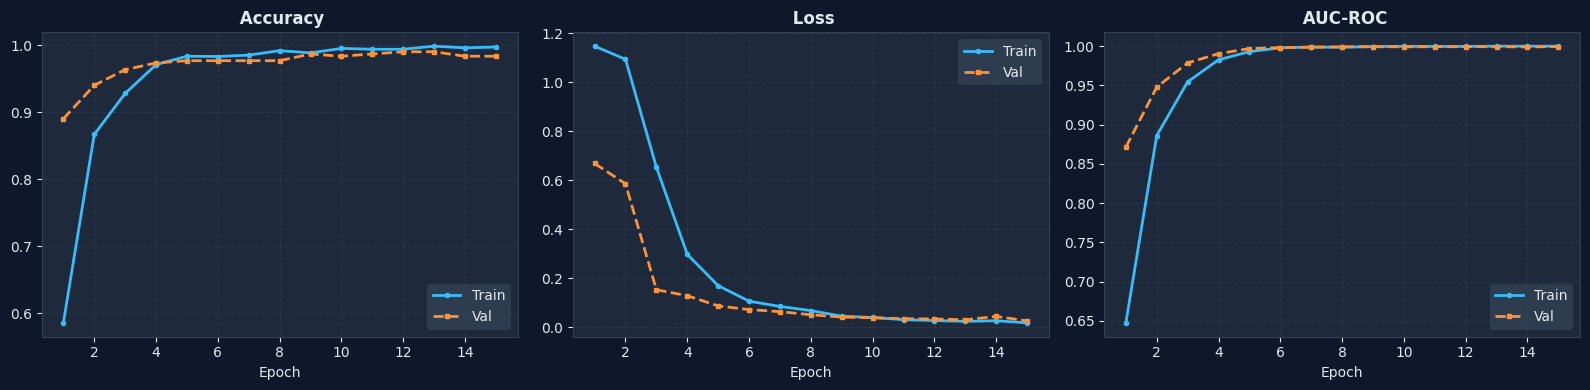

In [13]:
#  10. Plot training history
ep = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#0f172a')
BLUE   = '#38bdf8'
ORANGE = '#fb923c'
BG     = '#1e293b'
GRID   = '#334155'
WHITE  = '#e2e8f0'

def style(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=WHITE, fontweight='bold', fontsize=12)
    ax.tick_params(colors=WHITE)
    for spine in ax.spines.values(): spine.set_edgecolor(GRID)
    ax.grid(color=GRID, linestyle='--', alpha=0.6)
    ax.xaxis.label.set_color(WHITE); ax.yaxis.label.set_color(WHITE)

for ax, metric, title in zip(
        axes,
        ['accuracy', 'loss', 'auc'],
        [' Accuracy', ' Loss', ' AUC-ROC']):
    ax.plot(ep, history.history[metric],           color=BLUE,   lw=2, label='Train', marker='o', markersize=3)
    ax.plot(ep, history.history[f'val_{metric}'],  color=ORANGE, lw=2, label='Val',   marker='s', markersize=3, ls='--')
    style(ax, title)
    ax.set_xlabel('Epoch')
    ax.legend(facecolor=GRID, edgecolor='none', labelcolor=WHITE)

plt.tight_layout()
plt.show()


##  Evaluate on Test Set

In [14]:
# 11. Test evaluation
loss, acc, auc = model.evaluate(X_te, y_te, verbose=0)
y_prob = model.predict(X_te, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print("=" * 52)
print(f"  Test Accuracy  :  {acc*100:.2f}%")
print(f"  Test AUC-ROC   :  {auc:.4f}")
print(f"  Test Loss      :  {loss:.4f}")
print("=" * 52)
print()
print(classification_report(y_te, y_pred, target_names=['Ham (0)', 'Spam (1)']))


  Test Accuracy  :  99.67%
  Test AUC-ROC   :  0.9994
  Test Loss      :  0.0183

              precision    recall  f1-score   support

     Ham (0)       1.00      1.00      1.00       250
    Spam (1)       1.00      0.98      0.99        50

    accuracy                           1.00       300
   macro avg       1.00      0.99      0.99       300
weighted avg       1.00      1.00      1.00       300



### 🔢 Confusion Matrix & Score Distribution

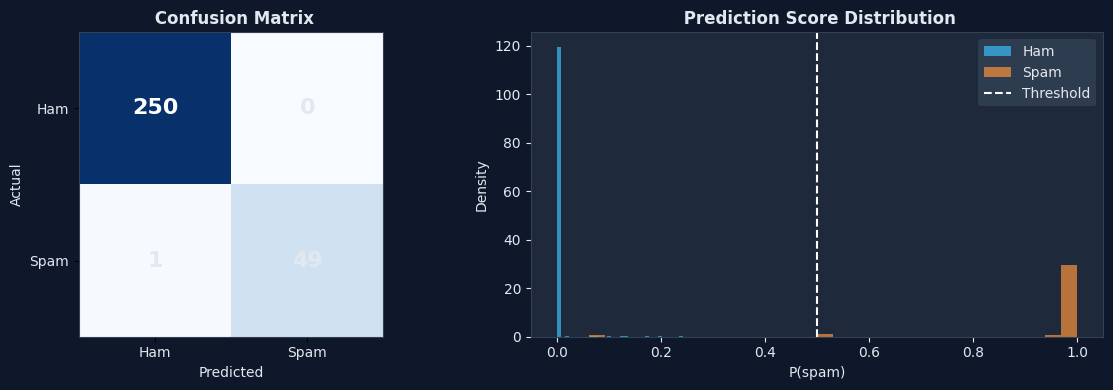

In [16]:
# 12. Confusion matrix & histogram
cm = confusion_matrix(y_te, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0f172a')

# Confusion matrix
ax = axes[0]
ax.set_facecolor(BG)
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else WHITE)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Ham','Spam'], color=WHITE)
ax.set_yticklabels(['Ham','Spam'], color=WHITE)
ax.set_xlabel('Predicted', color=WHITE); ax.set_ylabel('Actual', color=WHITE)
ax.set_title(' Confusion Matrix', color=WHITE, fontweight='bold', fontsize=12)
for spine in ax.spines.values(): spine.set_edgecolor(GRID)

# Score histogram
ax2 = axes[1]
ax2.set_facecolor(BG)
ax2.hist(y_prob[y_te==0], bins=30, color=BLUE,   alpha=0.7, label='Ham',  density=True)
ax2.hist(y_prob[y_te==1], bins=30, color=ORANGE, alpha=0.7, label='Spam', density=True)
ax2.axvline(0.5, color='white', ls='--', lw=1.5, label='Threshold')
ax2.set_title(' Prediction Score Distribution', color=WHITE, fontweight='bold', fontsize=12)
ax2.set_xlabel('P(spam)', color=WHITE); ax2.set_ylabel('Density', color=WHITE)
ax2.tick_params(colors=WHITE)
for spine in ax2.spines.values(): spine.set_edgecolor(GRID)
ax2.legend(facecolor=GRID, edgecolor='none', labelcolor=WHITE)

plt.tight_layout()
plt.show()


##  Live Inference — Try Your Own Emails

In [18]:
# 13. Predict function
def predict_email(text):
    seq    = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    prob   = model.predict(padded, verbose=0)[0][0]
    label  = '🔴 SPAM' if prob >= 0.5 else '✅ HAM '
    bar_len = int(prob * 30)
    bar = '█' * bar_len + '░' * (30 - bar_len)
    print(f"  {label}  [{bar}]  {prob*100:.1f}%")
    print(f"  Text: {text[:80]}...")
    print()

sample_emails = [
    "Congratulations! You've won a FREE iPhone. Click now to claim your prize!",
    "Hey, are you free for a quick call tomorrow at 2pm?",
    "URGENT! Your bank account has been compromised. Verify NOW to avoid suspension.",
    "Please find attached the meeting notes from today's discussion.",
    "WIN $1,000,000! You have been selected. Send your details IMMEDIATELY!",
]

print("=" * 70)
print("  Live Email Spam Detector")
print("=" * 70)
for email in sample_emails:
    predict_email(email)


  Live Email Spam Detector
  🔴 SPAM  [███████████████████████████░░░]  92.5%
  Text: Congratulations! You've won a FREE iPhone. Click now to claim your prize!...

  🔴 SPAM  [█████████████████████████░░░░░]  84.8%
  Text: Hey, are you free for a quick call tomorrow at 2pm?...

  ✅ HAM   [██████████░░░░░░░░░░░░░░░░░░░░]  34.6%
  Text: URGENT! Your bank account has been compromised. Verify NOW to avoid suspension....

  ✅ HAM   [████████████░░░░░░░░░░░░░░░░░░]  42.1%
  Text: Please find attached the meeting notes from today's discussion....

  🔴 SPAM  [██████████████████████████░░░░]  90.0%
  Text: WIN $1,000,000! You have been selected. Send your details IMMEDIATELY!...



## Save the Model

In [19]:
# ── 14. Save model & tokenizer ────────────────────────────────────────────────
import pickle, json

model.save('rnn_spam_model.keras')
print(" Model saved → rnn_spam_model.keras")

# Save tokenizer word index for later use
with open('tokenizer_word_index.json', 'w') as f:
    json.dump(tokenizer.word_index, f)
print(" Tokenizer saved → tokenizer_word_index.json")


 Model saved → rnn_spam_model.keras
 Tokenizer saved → tokenizer_word_index.json


##  Final Results Summary

In [20]:
#  15. Summary
results = {
    'Metric'   : ['Accuracy', 'AUC-ROC', 'Precision (Spam)', 'Recall (Spam)', 'F1-Score (Spam)'],
    'Value'    : [
        f'{acc*100:.2f}%',
        f'{auc:.4f}',
        f'{precision_score(y_te, y_pred):.4f}',
        f'{recall_score(y_te, y_pred):.4f}',
        f'{f1_score(y_te, y_pred):.4f}',
    ]
}
pd.DataFrame(results).style.set_properties(**{
    'background-color': '#1e293b',
    'color': '#e2e8f0',
    'border-color': '#334155'
}).hide(axis='index')


Metric,Value
Accuracy,99.67%
AUC-ROC,0.9994
Precision (Spam),1.0000
Recall (Spam),0.9800
F1-Score (Spam),0.9899
